# DAY 13 | End to End Toy Project

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
import pickle

## Reading the dataset

Reading the dataset from a CSV file using ```pd.read_csv()``` function into a dataframe

In [152]:
df = pd.read_csv("./placement.csv")

```df.head()``` will retrn the first 5 rows of the dataframe. It's primarily used to check how the dataset looks like, their fields and just a slice of the data

In [153]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


Understanding the dataset through ```df.info()```

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


## Data Preprocessing

We see that the first column is useless so we'll drop it

```df.iloc[]``` is used to extract rows from the dataframe in list slicing style

In [155]:
df = df.iloc[:, 1:] # all rows and 1 to all columns
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


## Exploratory Data Analysis

Plotting a graph between CGPA and IQ, along with their placement to try to understand any relationship

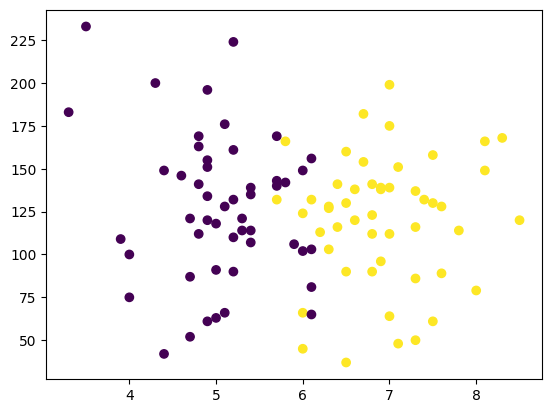

In [156]:
plt.scatter(df["cgpa"], df["iq"], c=df["placement"])

## Feature Selection

Here we are taking both the features, nothing much to do

## Extract input and output columns

Here `cgpa` and `iq` are called _independent_ variables

While, `placement` is the _dependent_ variable

We need to extract these variables seperately

In [157]:
X = df.iloc[:, :2] # all rows but only 0-2 columns
Y = df.iloc[:, -1] # all rows but only the last column

In [158]:
X.head()

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0


In [159]:
Y.head()

0    1
1    0
2    0
3    1
4    0
Name: placement, dtype: int64

## Train-test split

We are splitting the dataset in such a way that 10% goes to testing and rest 90% goes to training

In [160]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)

We see that random rows were picked up for training and testing partitions

In [161]:
X_train

,cgpa,iq
29,7.0,112.0
51,4.8,141.0
55,7.8,114.0
56,6.1,65.0
32,7.0,139.0
...,...,...
37,8.1,149.0
75,4.8,169.0
13,6.4,116.0
4,5.8,142.0


In [162]:
Y_train

29    1
51    0
55    1
56    0
32    1
     ..
37    1
75    0
13    1
4     0
22    0
Name: placement, Length: 90, dtype: int64

In [163]:
X_test

,cgpa,iq
42,7.6,89.0
18,4.0,100.0
40,4.9,134.0
30,7.6,128.0
87,5.7,132.0
95,4.3,200.0
44,7.5,61.0
82,6.5,37.0
67,5.0,118.0
46,5.3,114.0


In [164]:
Y_test

42    1
18    0
40    0
30    1
87    1
95    0
44    1
82    1
67    0
46    0
Name: placement, dtype: int64

## Scaling the values

Scaling is not essential always, but it's better to do

In [165]:
scaler = StandardScaler()

`.fit_transform()` understands the pattern and then scales the data

In [166]:
X_train = scaler.fit_transform(X_train)
X_train

array([[ 0.88871737, -0.33001608],
       [-1.08178699,  0.40933325],
       [ 1.60526441, -0.27902647],
       [ 0.08260195, -1.52827189],
       [ 0.88871737,  0.35834364],
       [ 0.79914899,  0.35834364],
       [-0.81308185, -1.50277709],
       [-1.26092375,  0.53680727],
       [ 1.15742251, -0.992881  ],
       [ 1.15742251, -1.91069396],
       [-1.08178699, -0.33001608],
       [-0.00696643, -2.03816798],
       [-1.44006051,  0.61329169],
       [ 1.87396955,  1.04670336],
       [-1.88790241, -0.40650049],
       [ 0.26173871, -0.55946932],
       [-1.17135537, -1.85970435],
       [-1.44006051, -2.11465239],
       [-2.24617593,  2.75485526],
       [ 0.17217033, -0.30452128],
       [ 0.44087547,  0.89373453],
       [-1.17135537, -0.96738619],
       [-0.90265023, -1.5792615 ],
       [-0.27567157,  1.12318777],
       [ 0.44087547,  0.1288904 ],
       [-0.99221861,  0.76626051],
       [ 0.44087547, -0.89090178],
       [ 0.70958061,  0.40933325],
       [-0.54437671,

No need to `.fit_transform()` again. As we already have understood the pattern in the last step. We can simply use `.transform()` here

In [167]:
X_test = scaler.transform(X_test)
X_test

array([[ 1.42612765, -0.91639658],
       [-1.79833403, -0.63595373],
       [-0.99221861,  0.23086962],
       [ 1.42612765,  0.07790079],
       [-0.27567157,  0.17988001],
       [-1.52962889,  1.91352671],
       [ 1.33655927, -1.63025111],
       [ 0.44087547, -2.24212641],
       [-0.90265023, -0.17704725],
       [-0.63394509, -0.27902647]])

## Training the model

We are trying to train a Logistic Regression Model

In [168]:
clf = LogisticRegression()

In [169]:
clf.fit(X_train, Y_train) # so easy xD

LogisticRegression()

## Evaluate the Model

Now we run the model on the test dataset

In [170]:
Y_pred = clf.predict(X_test)

We can then compare with the `Y_test` to see how well our model is performing. We can do it manually, but better to use libraries. Here we are using `accuracy_score`

In [171]:
accuracy_score(Y_test, Y_pred)

0.9

### Plotting the decision boundary

We'll use a library called `mlxtend` to plot the decision boundary

<Axes: >

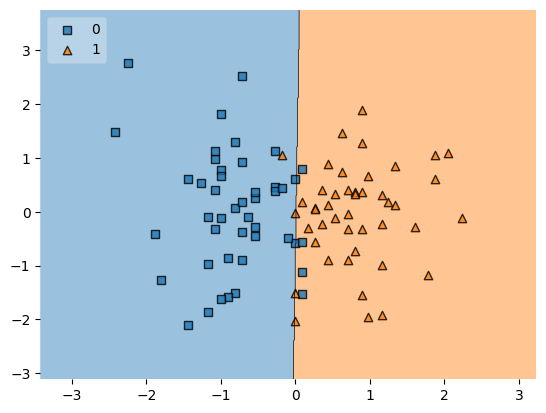

In [177]:
plot_decision_regions(X_train, Y_train.values, clf=clf, legend=2)

## Model Selection

No need to do any model selection, as we have trained only one model here

## Exporting the model

We can export the model using the `pickle` library. It is used to convert a python object to a binary file, so that we can use it somewhere later.

In [179]:
pickle.dump(clf, open("model.pkl", "wb"))